# IMPORT OF LIBRARIES

- INSTALLATION

In [399]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


- IMPORT

In [370]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import joblib

import warnings
warnings.filterwarnings('ignore')

# LOAD OF DATASETS

In [371]:
matches = pd.read_csv("../data/raw_data/ipl_matches_data.csv", encoding="latin1")
deliveries = pd.read_csv("../data/raw_data/ball_by_ball_data.csv", encoding="latin1")

In [372]:
matches.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result,stage
0,335982,2008,6,Bangalore,18-04-2008,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,field,Kolkata Knight Riders,140.0,NaN,46.0,win,NaN
1,1082591,2017,6,Hyderabad,05-04-2017,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,15.0,win,NaN
2,1082592,2017,6,Pune,06-04-2017,Indian Premier League,2.0,male,T20,T20,...,Rising Pune Supergiant,Rising Pune Supergiant,Mumbai Indians,field,Rising Pune Supergiant,NaN,7.0,36.0,win,NaN
3,1082593,2017,6,Rajkot,07-04-2017,Indian Premier League,3.0,male,T20,T20,...,Kolkata Knight Riders,Gujarat Lions,Kolkata Knight Riders,field,Kolkata Knight Riders,NaN,10.0,57.0,win,NaN
4,1082594,2017,6,Indore,08-04-2017,Indian Premier League,4.0,male,T20,T20,...,Punjab Kings,Punjab Kings,Rising Pune Supergiant,field,Punjab Kings,NaN,6.0,71.0,win,NaN


In [373]:
matches.columns

Index(['match_id', 'season_id', 'balls_per_over', 'city', 'match_date',
       'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs',
       'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2',
       'toss_decision', 'match_winner', 'win_by_runs', 'win_by_wickets',
       'player_of_match', 'result', 'stage'],
      dtype='object')

In [374]:
deliveries.head()

,season_id,match_id,batter,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batter_runs,...,is_bye,is_penalty,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,Kolkata Knight Riders,Royal Challengers Bangalore,0,0,0,...,False,False,0,0,1,0,0,NaN,False,1
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0,...,False,False,0,0,0,0,0,NaN,False,1
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,...,False,False,1,0,0,0,0,NaN,False,1
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0,...,False,False,0,0,0,0,0,NaN,False,1
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0,...,False,False,0,0,0,0,0,NaN,False,1


In [375]:
deliveries.columns

Index(['season_id', 'match_id', 'batter', 'bowler', 'non_striker',
       'team_batting', 'team_bowling', 'over_number', 'ball_number',
       'batter_runs', 'extras', 'total_runs', 'batsman_type', 'bowler_type',
       'player_out', 'fielders_involved', 'is_wicket', 'is_wide_ball',
       'is_no_ball', 'is_leg_bye', 'is_bye', 'is_penalty', 'wide_ball_runs',
       'no_ball_runs', 'leg_bye_runs', 'bye_runs', 'penalty_runs',
       'wicket_kind', 'is_super_over', 'innings'],
      dtype='object')

In [376]:
delivery_df = deliveries.merge(
    matches[['match_id', 'venue','match_date']],
    left_on='match_id',
    right_on='match_id',
    how='left'
)

In [377]:
delivery_df.head()

,season_id,match_id,batter,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batter_runs,...,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings,venue,match_date
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,Kolkata Knight Riders,Royal Challengers Bangalore,0,0,0,...,0,0,1,0,0,NaN,False,1,M Chinnaswamy Stadium,18-04-2008
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0,...,0,0,0,0,0,NaN,False,1,M Chinnaswamy Stadium,18-04-2008
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,...,1,0,0,0,0,NaN,False,1,M Chinnaswamy Stadium,18-04-2008
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0,...,0,0,0,0,0,NaN,False,1,M Chinnaswamy Stadium,18-04-2008
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0,...,0,0,0,0,0,NaN,False,1,M Chinnaswamy Stadium,18-04-2008


# CREATE TEAM MATCH SCORES
We forecast team scores over matches.

- <b> Aggregate team scores

In [378]:
team_scores = delivery_df.groupby(['match_id','match_date','team_batting','team_bowling','venue',])['total_runs'].sum().reset_index()

In [379]:
team_scores.head()

,match_id,match_date,team_batting,team_bowling,venue,total_runs
0,335982,18-04-2008,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,222
1,335982,18-04-2008,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,82
2,335983,19-04-2008,Chennai Super Kings,Punjab Kings,"Punjab Cricket Association Stadium, Mohali",240
3,335983,19-04-2008,Punjab Kings,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",207
4,335984,19-04-2008,Delhi Capitals,Rajasthan Royals,Feroz Shah Kotla,132


- <b> convert date

In [380]:
team_scores['match_date'] = pd.to_datetime(team_scores['match_date'])

# SELECT ONE TEAM

In [381]:
team_name = "Chennai Super Kings"

team_data = team_scores[team_scores['team_batting'] == team_name]

# SORT CHRONOLOGICALLY

In [382]:
team_data = team_data.sort_values('match_date')

# CREATE TIME SERIES

In [383]:
series = team_data['total_runs']

# TRAIN ARIMA MODEL

In [384]:
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

In [385]:
model = ARIMA(series, order=(5,1,1))

model_fit = model.fit()

- WHAT DOES (3,1,1) MEAN?<br>
p = autoregressive terms<br>
d = differencing<br>
q = moving average terms

# FORECAST

Forecast next 5 matches.

In [386]:
forecast = model_fit.forecast(steps=10)

print(forecast)

251    172.894956
252    176.874229
253    175.356911
254    177.381055
255    173.186829
256    173.686635
257    173.414101
258    173.495724
259    173.187640
260    173.232583
Name: predicted_mean, dtype: float64


# SAVE MODEL

In [387]:
joblib.dump(model_fit, "../models/arima_model.pkl")

['../models/arima_model.pkl']

In [388]:
team_scores = pd.read_csv("../models/team_scores.csv")

In [389]:
team_scores.to_csv("../models/team_scores.csv", index=False)

# MODEL EVALUATION

In [390]:
forecast = model_fit.forecast(
    steps=len(test)
)

In [391]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [392]:
mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

MAE: 23.51
RMSE: 30.11


# VIZUALIZATION

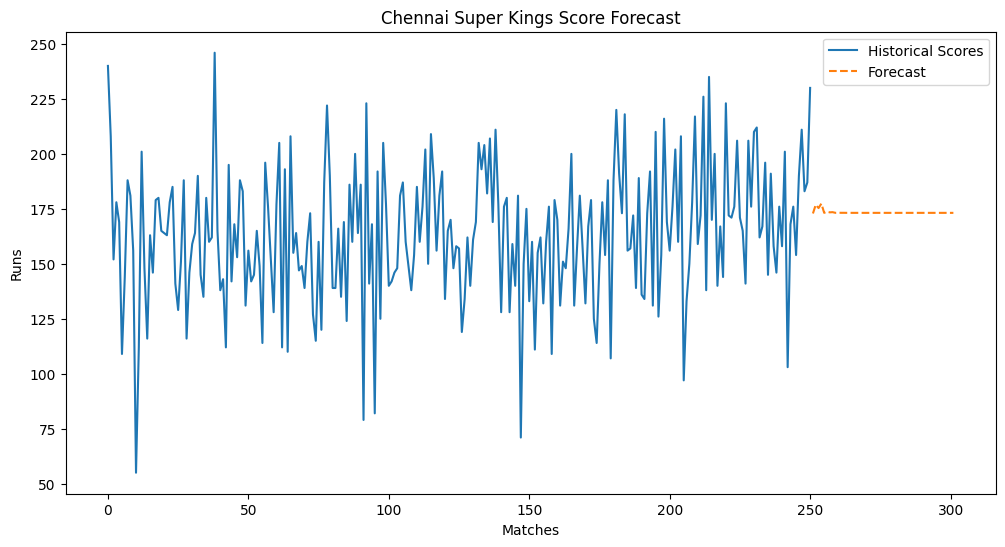

In [393]:
plt.figure(figsize=(12,6))

plt.plot(series.values, label="Historical Scores")

forecast_index = range(
    len(series),
    len(series) + len(forecast)
)

plt.plot(
    forecast_index,
    forecast.values,
    label="Forecast",
    linestyle='dashed'
)

plt.legend()

plt.title(f"{team_name} Score Forecast")

plt.xlabel("Matches")
plt.ylabel("Runs")

plt.show()

### ADF test
- To determine -> d<br>

If: p-value < 0.05 (Series is stationary).<br>
    Then:   d = 0 <br>

If: p-value > 0.05 (Need differencing)<br>
    Then:   d = 1 

In [394]:
# Stationarity test

from statsmodels.tsa.stattools import adfuller

result = adfuller(series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -10.68145158664629
p-value: 3.930729653542983e-19


### PACF FOR P

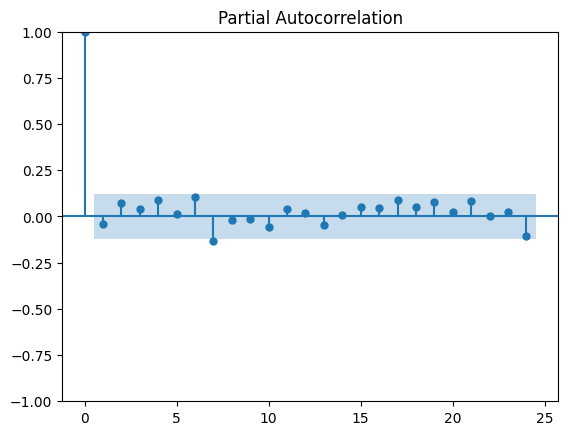

In [395]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(series)
plt.show()

### ACF FOR Q

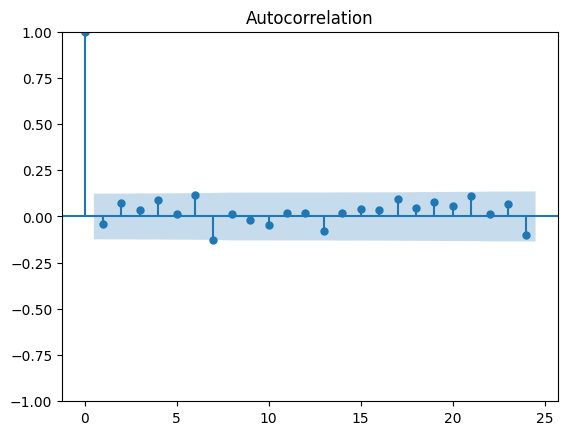

In [396]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(series)
plt.show()

### AUTO-ARIMA MODEL

In [397]:
%pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [398]:
from pmdarima import auto_arima

auto_model = auto_arima(
    series,
    seasonal=False,
    trace=True
)

print(auto_model.order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2608.571, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2517.613, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2606.571, Time=0.15 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2489.998, Time=0.06 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=2469.719, Time=0.09 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=2464.320, Time=0.10 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=2453.947, Time=0.17 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(5,1,0)(0,0,0)[0]             : AIC=2451.951, Time=0.08 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=2462.321, Time=0.06 sec
 ARIMA(5,1,1)(0,0,0)[0]             : AIC=2438.187, Time=0.17 sec
 ARIMA(4,1,1)(0,0,0)[0]             : AIC=2436.188, T